<a href="https://colab.research.google.com/github/white-I-I/ML--experiments-/blob/main/ex_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv', 'titanic']

In [8]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

Columns in the DataFrame after loading placement_dataset.csv:
Index(['CGPA', 'IQ', 'Aptitude_Score', 'Communication_Skill', 'Internships',
       'Branch', 'Placed'],
      dtype='object')


,CGPA,IQ,Aptitude_Score,Communication_Skill,Internships,Branch,Placed
0,8.00,81.0,89.0,1,1,MECH,No
1,7.36,105.0,74.0,5,3,CIVIL,Yes
2,8.15,96.0,62.0,6,1,IT,No
3,9.02,119.0,56.0,6,2,CSE,No
4,NaN,NaN,NaN,3,3,CSE,Yes


Accuracy: 0.55
              precision    recall  f1-score   support

          No       0.47      0.53      0.50        17
         Yes       0.62      0.57      0.59        23

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.56      0.55      0.55        40

Saved tree image.


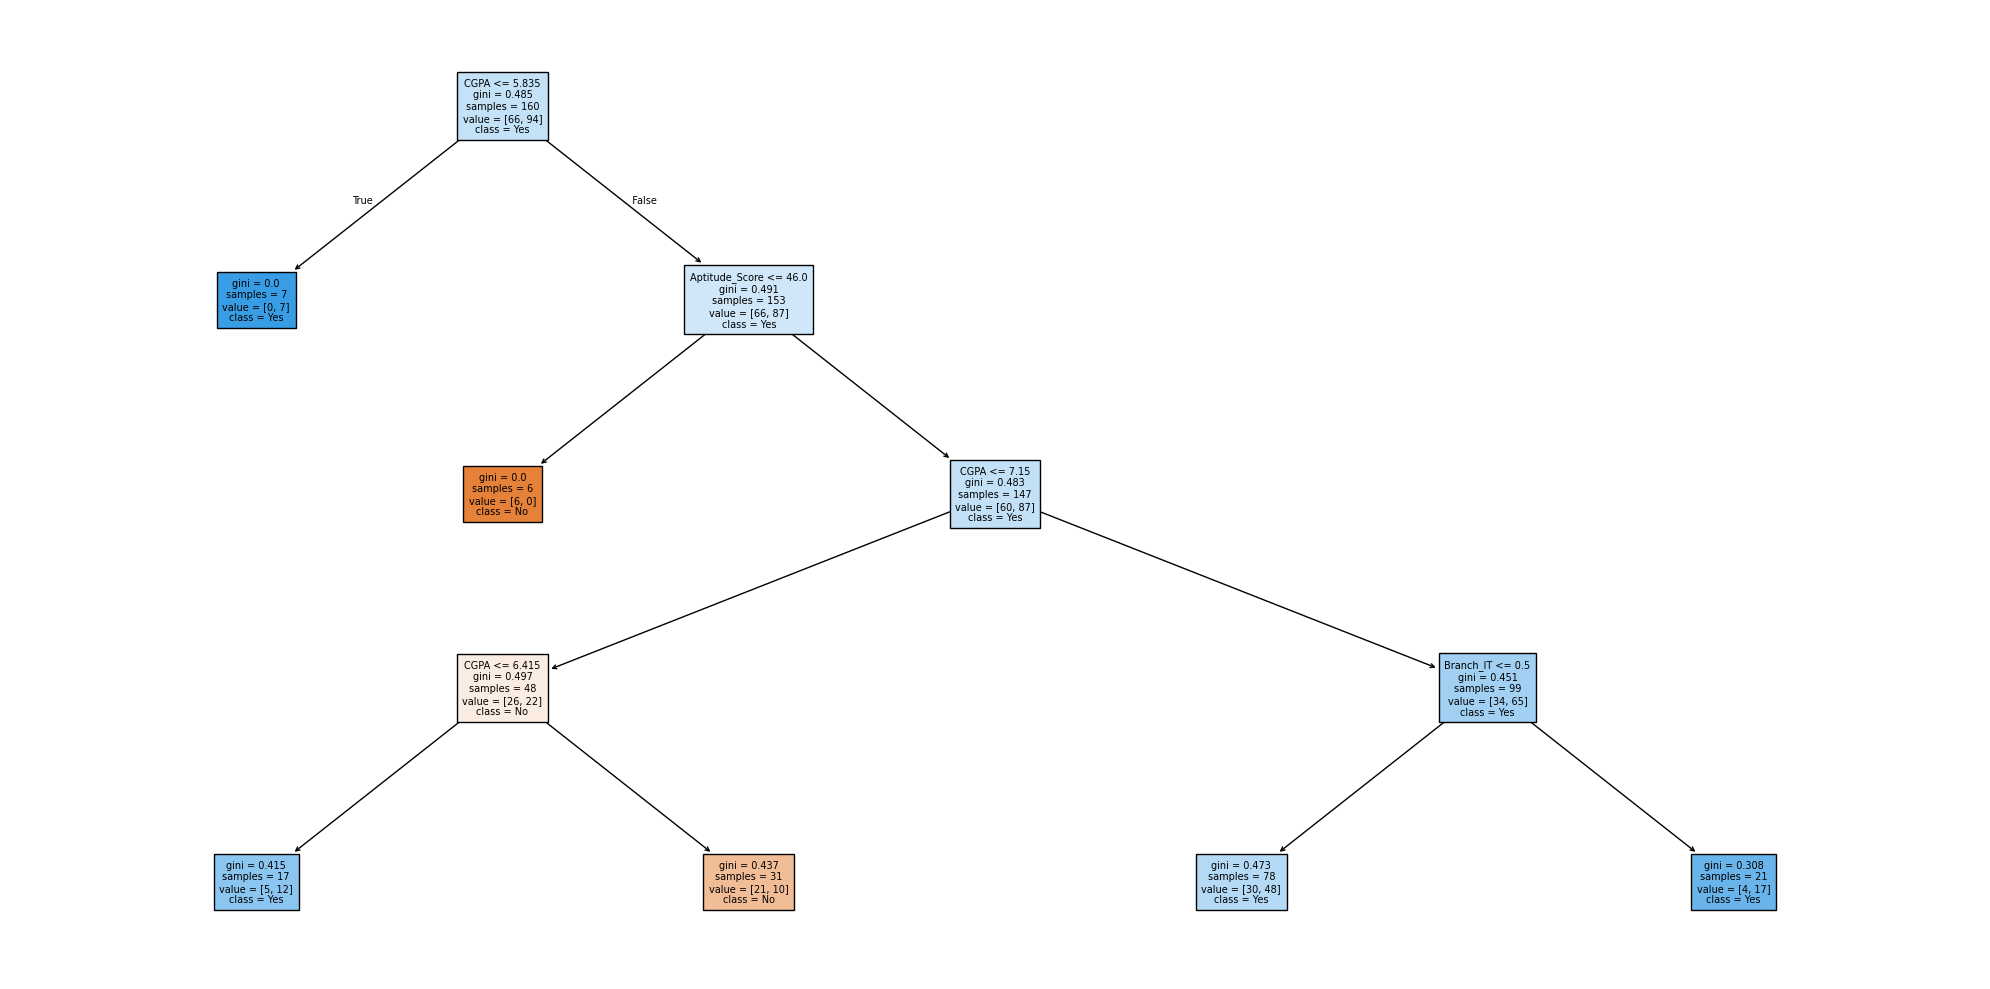

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')
# The dataframe 'df' is now explicitly loaded from placement_dataset.csv.

print("Columns in the DataFrame after loading placement_dataset.csv:")
print(df.columns)
display(df.head())

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df_encoded = pd.get_dummies(df, columns=[
    'Branch'
], drop_first=True)

X = df_encoded.drop(columns=['Placed'])
y = df_encoded['Placed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved tree image.")